In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('/content/survey_results_public.csv')

In [3]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [4]:
cols = ['Country', 'Age', 'EdLevel', 'YearsCodePro', 'DevType',
        'Employment', 'RemoteWork', 'LanguageHaveWorkedWith',
        'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith',
        'ConvertedCompYearly']

df = df[cols]
df.head()

,Country,Age,EdLevel,YearsCodePro,DevType,Employment,RemoteWork,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,ConvertedCompYearly
0,United States of America,Under 18 years old,Primary/elementary school,NaN,NaN,"Employed, full-time",Remote,NaN,NaN,NaN,NaN
1,United Kingdom of Great Britain and Northern I...,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Developer, full-stack","Employed, full-time",Remote,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,NaN
2,United Kingdom of Great Britain and Northern I...,45-54 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",27,Developer Experience,"Employed, full-time",Remote,C#,Firebase Realtime Database,Google Cloud,NaN
3,Canada,18-24 years old,Some college/university study without earning ...,NaN,"Developer, full-stack","Student, full-time",NaN,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,MongoDB;MySQL;PostgreSQL;SQLite,Amazon Web Services (AWS);Fly.io;Heroku,NaN
4,Norway,18-24 years old,"Secondary school (e.g. American high school, G...",NaN,"Developer, full-stack","Student, full-time",NaN,C++;HTML/CSS;JavaScript;Lua;Python;Rust,PostgreSQL;SQLite,NaN,NaN


In [5]:
df.isnull().sum()

,0
Country,6507
Age,0
EdLevel,4653
YearsCodePro,13827
DevType,5992
Employment,0
RemoteWork,10631
LanguageHaveWorkedWith,5692
DatabaseHaveWorkedWith,15183
PlatformHaveWorkedWith,23071


In [6]:
# Drop rows where salary is missing — can't train on unknown targets
df = df.dropna(subset=['ConvertedCompYearly'])

In [7]:
# Remove unrealistic salary outliers (keep between $1,000 and $500,000)
df = df[(df['ConvertedCompYearly'] >= 1000) & (df['ConvertedCompYearly'] <= 500000)]

print("Shape after cleaning target:", df.shape)
df['ConvertedCompYearly'].describe()

Shape after cleaning target: (22765, 11)


,ConvertedCompYearly
count,22765.000000
mean,81416.627015
std,66497.400536
min,1000.000000
25%,35890.000000
50%,66592.000000
75%,108587.000000
max,500000.000000


In [8]:
# Clean YearsCodePro (text → number)
def clean_years(val):
    if pd.isna(val):
        return np.nan
    if val == 'Less than 1 year':
        return 0
    if val == 'More than 50 years':
        return 51
    try:
        return int(val)
    except:
        return np.nan

df['YearsCodePro'] = df['YearsCodePro'].apply(clean_years)
df['YearsCodePro'] = df['YearsCodePro'].fillna(df['YearsCodePro'].median())

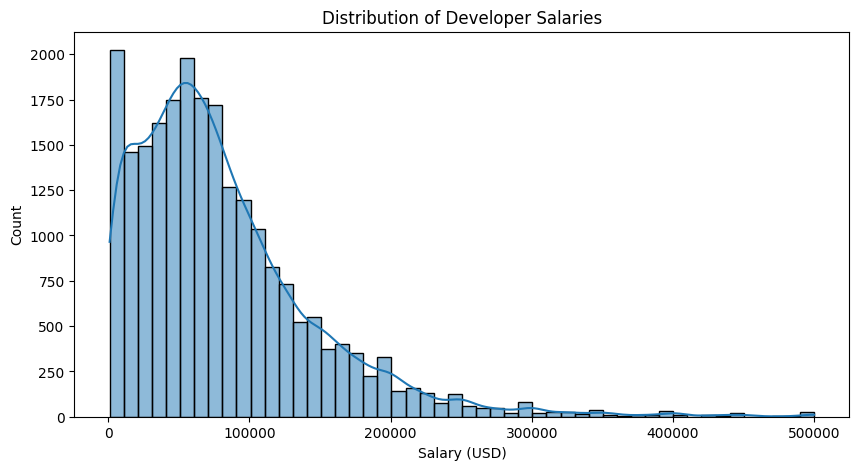

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['ConvertedCompYearly'], bins=50, kde=True)
plt.title("Distribution of Developer Salaries")
plt.xlabel("Salary (USD)")
plt.ylabel("Count")
plt.show()

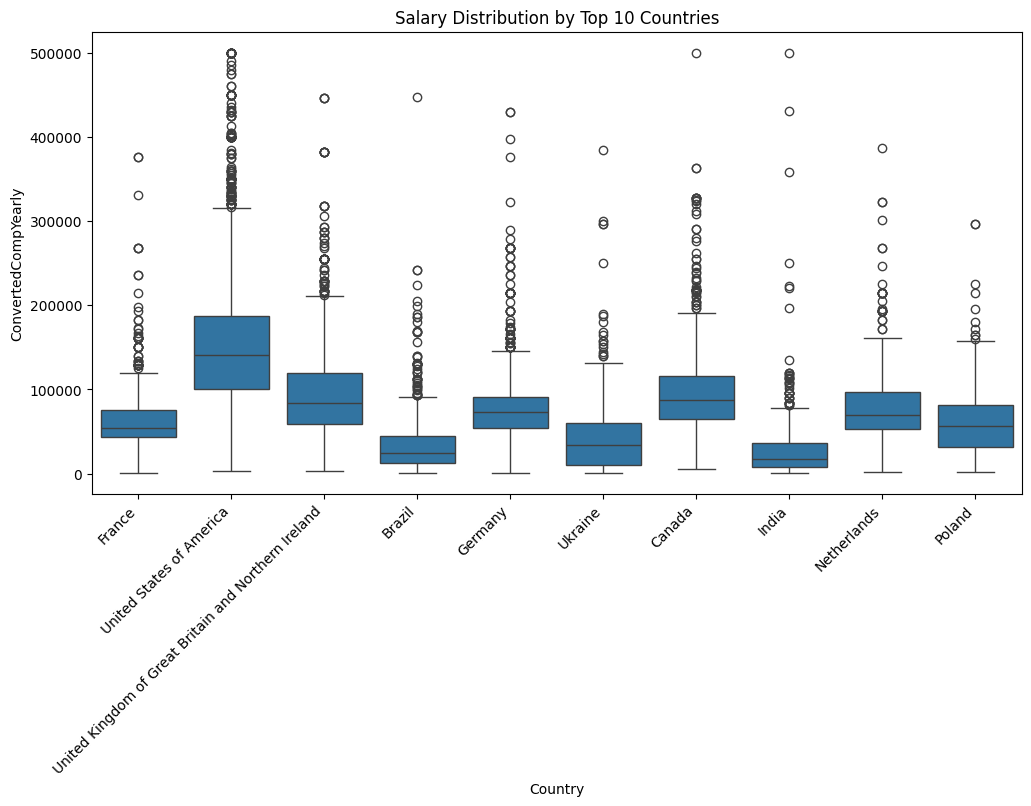

In [10]:
top_countries = df['Country'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['Country'].isin(top_countries)],
            x='Country', y='ConvertedCompYearly')
plt.xticks(rotation=45, ha='right')
plt.title("Salary Distribution by Top 10 Countries")
plt.show()

## **A boxplot shows the salary spread (median, quartiles, outliers) for each of the 10 most common countries in the survey. This usually reveals huge gaps — e.g., US/Switzerland salaries dwarf many other countries — confirming Country will be a strong predictor.**

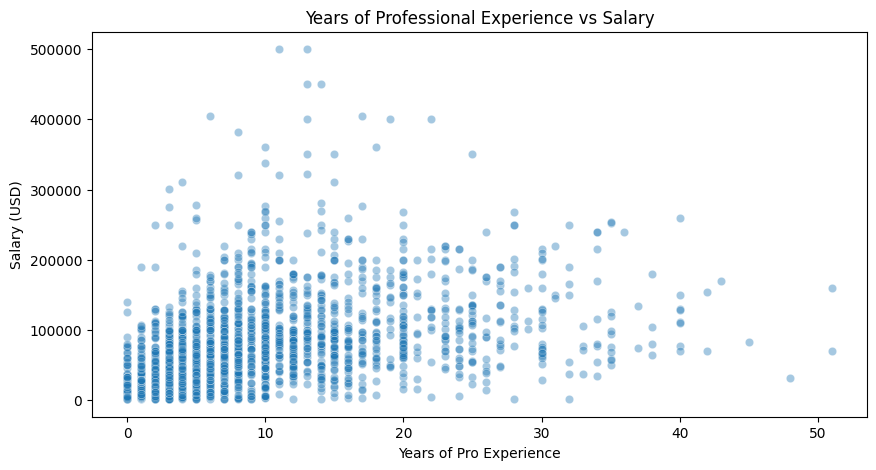

In [11]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.sample(2000), x='YearsCodePro', y='ConvertedCompYearly', alpha=0.4)
plt.title("Years of Professional Experience vs Salary")
plt.xlabel("Years of Pro Experience")
plt.ylabel("Salary (USD)")
plt.show()

## We sample 2,000 rows (plotting all 65k points would be unreadably dense) to visualize whether salary rises with experience. Expect a rough upward trend but with lots of scatter — real-world data is noisy, this isn't a clean line.

In [12]:
def top_n_binarize(df, col, n=10):
    df[col] = df[col].fillna('')
    all_items = df[col].str.split(';').explode()
    top_items = all_items.value_counts().head(n).index

    for item in top_items:
        clean_name = f"{col}_{item.strip().replace(' ', '_').replace('/', '_')}"
        df[clean_name] = df[col].apply(lambda x: 1 if item in x else 0)

    return df.drop(columns=[col])

df = top_n_binarize(df, 'LanguageHaveWorkedWith', n=10)
df = top_n_binarize(df, 'DatabaseHaveWorkedWith', n=8)
df = top_n_binarize(df, 'PlatformHaveWorkedWith', n=8)

print("Shape after tech encoding:", df.shape)

Shape after tech encoding: (22765, 34)


In [13]:
#ENCODE COL
categorical_cols = ['Country', 'Age', 'EdLevel', 'DevType', 'Employment', 'RemoteWork']

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# Keep top 15 countries, group rest as "Other" (reduces high cardinality)
top_countries = df['Country'].value_counts().head(15).index
df['Country'] = df['Country'].apply(lambda x: x if x in top_countries else 'Other')

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Final shape:", df.shape)

Final shape: (22765, 146)


In [14]:
X = df.drop(columns=['ConvertedCompYearly'])
y = df['ConvertedCompYearly']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (18212, 145) Test size: (4553, 145)


**LINEAR REGRESSION (BASELINE)**

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression -> RMSE: {lr_rmse:.2f}, MAE: {lr_mae:.2f}, R²: {lr_r2:.3f}")

Linear Regression -> RMSE: 45392.15, MAE: 29524.67, R²: 0.525


**RANDOM FOREST**

In [16]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest -> RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}, R²: {rf_r2:.3f}")

Random Forest -> RMSE: 45624.43, MAE: 29281.82, R²: 0.520


               Model          RMSE           MAE  R2 Score
0  Linear Regression  45392.146599  29524.667452  0.525247
1      Random Forest  45624.427281  29281.822353  0.520376


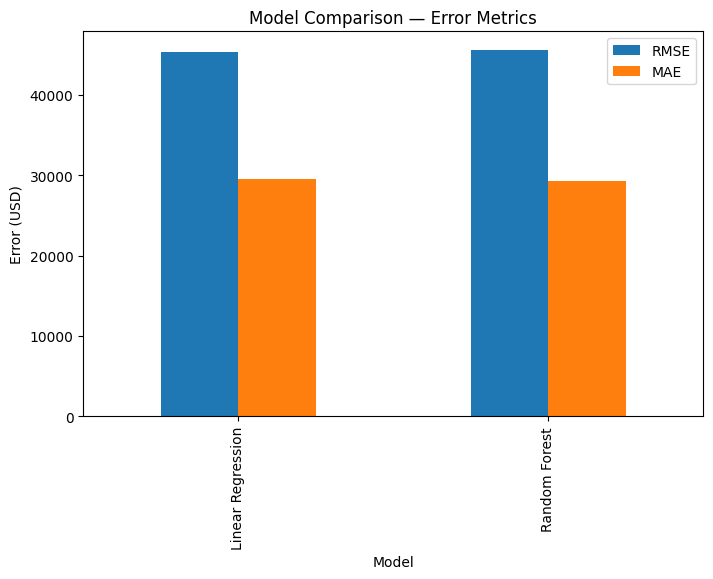

In [18]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae],
    'R2 Score': [lr_r2, rf_r2]
})
print(results)

results.set_index('Model')[['RMSE', 'MAE']].plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison — Error Metrics")
plt.ylabel("Error (USD)")
plt.show()

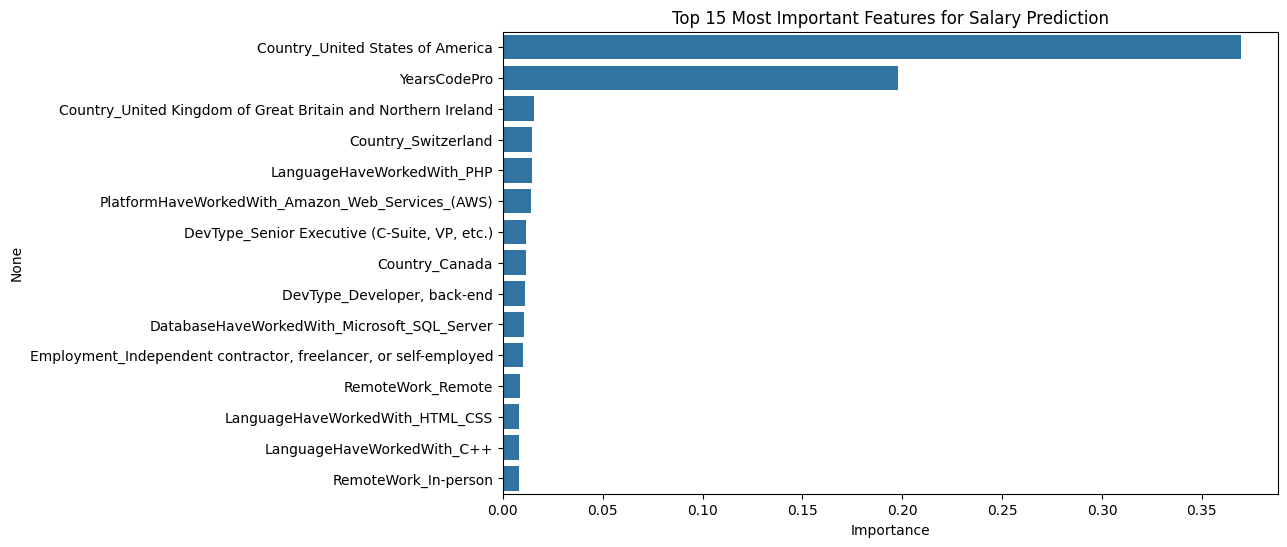

In [19]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Most Important Features for Salary Prediction")
plt.xlabel("Importance")
plt.show()

In [20]:
# Build a single custom input row matching your training columns
new_dev = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

# Example: set values for a hypothetical developer
new_dev['YearsCodePro'] = 5
if 'Country_India' in new_dev.columns:
    new_dev['Country_India'] = 1
if 'DevType_Data scientist or machine learning specialist' in new_dev.columns:
    new_dev['DevType_Data scientist or machine learning specialist'] = 1
if 'LanguageHaveWorkedWith_Python' in new_dev.columns:
    new_dev['LanguageHaveWorkedWith_Python'] = 1

predicted_salary = rf_model.predict(new_dev)
print(f"Predicted Salary: ${predicted_salary[0]:,.2f}")

Predicted Salary: $21,561.46
